Round 1 Informed Trader Detection

In [1]:
# Setup: imports, paths, and plotting defaults
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent

SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from imc_eda.round1 import DEFAULT_DATA_DIR, build_price_features, load_prices, load_trades

sns.set_theme(style='whitegrid', context='notebook')
FIGURES_DIR = ROOT / 'reports' / 'figures' / 'round1'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RESIN_CANDIDATE = 'ASH_COATED_OSMIUM'
KELP_CANDIDATE = 'INTARIAN_PEPPER_ROOT'
RESIN_FAIR = 10_000

ROOT, DEFAULT_DATA_DIR

(PosixPath('/home/yee/Documents/imc-prosperity'),
 PosixPath('/home/yee/Documents/imc-prosperity/data/round 1'))

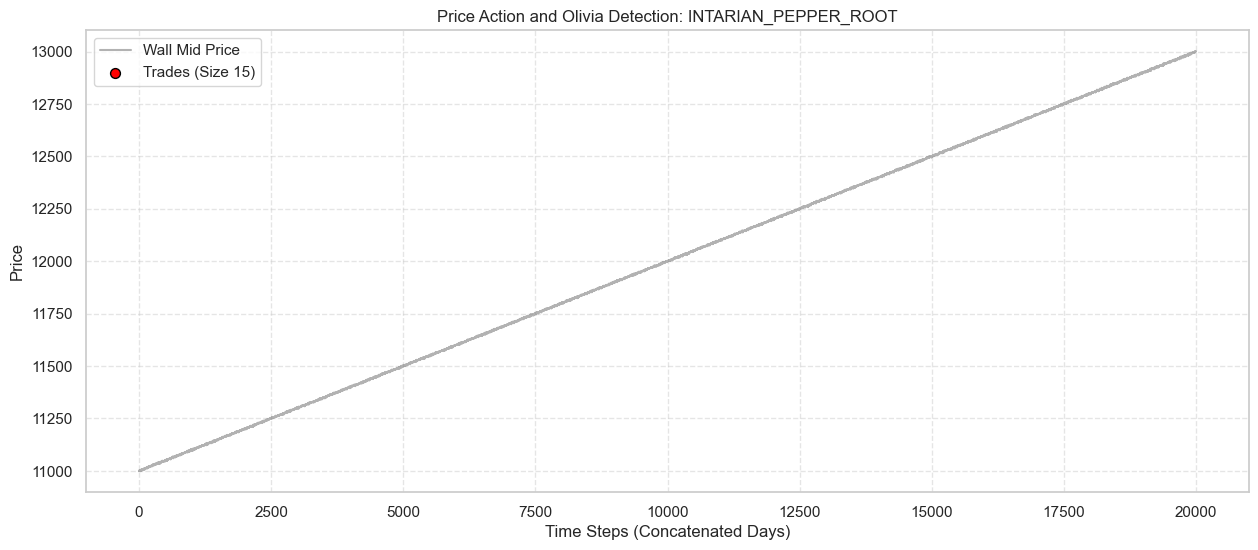

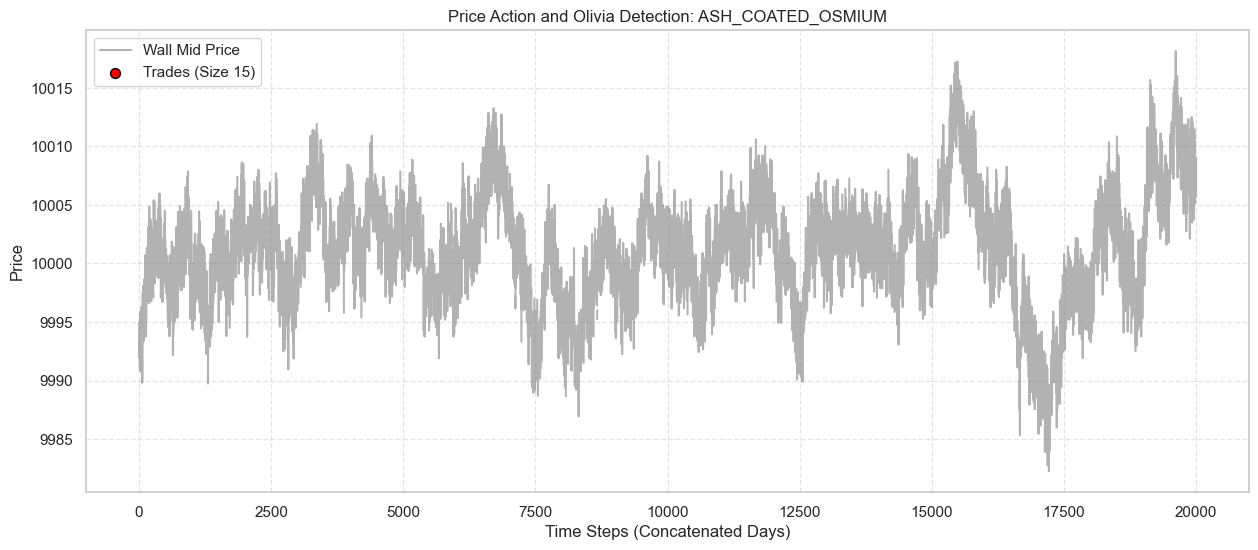

Detected quantities at daily extremes:
Day -1 | INTARIAN_PEPPER_ROOT: Low Qties: [4], High Qties: [4]
Day -1 | ASH_COATED_OSMIUM: Low Qties: [4], High Qties: [9]
Day 0 | INTARIAN_PEPPER_ROOT: Low Qties: [4], High Qties: [4]
Day 0 | ASH_COATED_OSMIUM: Low Qties: [4], High Qties: [9]


In [4]:
# Constants for data loading
DAYS = [-1, 0, 1]
ROUND = 1

def load_data(directory):
    price_dfs = []
    trade_dfs = []
    
    for day in DAYS:
        p_path = Path(directory) / f"prices_round_{ROUND}_day_{day}.csv"
        t_path = Path(directory) / f"trades_round_{ROUND}_day_{day}.csv"
        
        if p_path.exists():
            # Price files use ';' as separator
            df_p = pd.read_csv(p_path, sep=';')
            price_dfs.append(df_p)
            
        if t_path.exists():
            # Trade files also use ';'
            df_t = pd.read_csv(t_path, sep=';')
            trade_dfs.append(df_t)
            
    return pd.concat(price_dfs), pd.concat(trade_dfs)

# 1. Load Data
prices, trades = load_data(DEFAULT_DATA_DIR)

# 2. Calculate Wall Mid (Weighted Mid)
# Formula: (BidPrice1 * AskVol1 + AskPrice1 * BidVol1) / (BidVol1 + AskVol1)
prices['wall_mid'] = (
    (prices['bid_price_1'] * prices['ask_volume_1']) + 
    (prices['ask_price_1'] * prices['bid_volume_1'])
) / (prices['bid_volume_1'] + prices['ask_volume_1'])

# 3. Identify Daily Extremes and Significant Sizes
results = []
products = prices['product'].unique()

for day in DAYS:
    for product in products:
        day_prices = prices[(prices['day'] == day) & (prices['product'] == product)]
        day_trades = trades[(trades['timestamp'].isin(day_prices['timestamp'])) & (trades['symbol'] == product)]
        
        if day_prices.empty or day_trades.empty:
            continue
            
        # Find daily extremes based on the executed trade prices
        daily_low = day_trades['price'].min()
        daily_high = day_trades['price'].max()
        
        # Get quantities traded at these exact extremes
        low_qty = day_trades[day_trades['price'] == daily_low]['quantity'].unique()
        high_qty = day_trades[day_trades['price'] == daily_high]['quantity'].unique()
        
        # Store for plotting (Focusing on the 15-lot pattern mentioned)
        results.append({
            'day': day,
            'product': product,
            'low_sizes': low_qty,
            'high_sizes': high_qty
        })

# 4. Visualization
for product in products:
    plt.figure(figsize=(15, 6))
    product_prices = prices[prices['product'] == product].sort_values(['day', 'timestamp'])
    
    # We use a continuous index for the x-axis to avoid gaps between days
    product_prices = product_prices.reset_index(drop=True)
    plt.plot(product_prices.index, product_prices['wall_mid'], label='Wall Mid Price', alpha=0.6, color='gray')
    
    # Highlight potential Olivia trades (assuming 15 is our target quantity)
    target_qty = 15
    product_trades = trades[trades['symbol'] == product]
    
    # Merge with price index to align timestamps for plotting
    plot_data = product_trades.merge(
        product_prices[['day', 'timestamp']], 
        on=['timestamp'], 
        how='inner'
    )
    
    # Filter for the specific size "15"
    olivia_trades = plot_data[plot_data['quantity'] == target_qty]
    
    plt.scatter(
        olivia_trades.index, 
        olivia_trades['price'], 
        color='red', 
        label=f'Trades (Size {target_qty})', 
        s=50, 
        edgecolor='black', 
        zorder=5
    )
    
    plt.title(f"Price Action and Olivia Detection: {product}")
    plt.xlabel("Time Steps (Concatenated Days)")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Print summary of sizes found at extremes to verify the '15' lot hypothesis
print("Detected quantities at daily extremes:")
for res in results:
    print(f"Day {res['day']} | {res['product']}: Low Qties: {res['low_sizes']}, High Qties: {res['high_sizes']}")

Trade sizes with the highest average price impact (Next 10 ticks):


<>:58: SyntaxWarning: invalid escape sequence '\D'
<>:58: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_18518/4114582696.py:58: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("Price Delta ($\Delta P$)")


,quantity,mean,std,count,abs_mean_impact
6,8,1.037472,3.664615,68,1.037472
5,7,0.905547,2.700202,167,0.905547
2,4,0.688477,2.379047,190,0.688477
1,3,0.533522,2.427870,212,0.533522
4,6,0.421709,2.401307,257,0.421709
7,9,0.364138,1.920987,46,0.364138
3,5,0.220265,2.458156,267,0.220265
8,10,0.218616,1.864937,46,0.218616
0,2,-0.079803,1.970537,99,0.079803


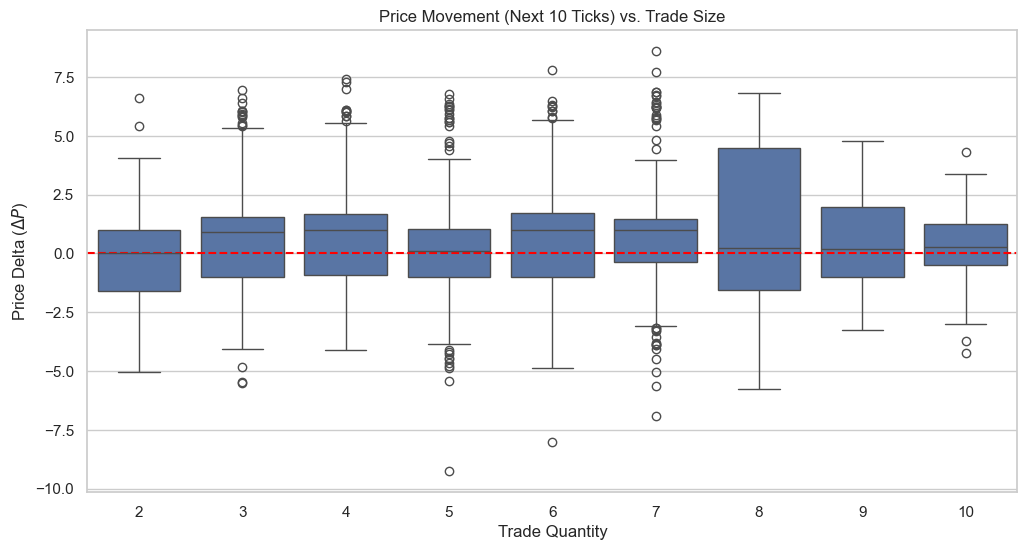

In [12]:
def load_data_fixed(directory):
    price_dfs = []
    trade_dfs = []
    
    for day in DAYS:
        p_path = Path(directory) / f"prices_round_{ROUND}_day_{day}.csv"
        t_path = Path(directory) / f"trades_round_{ROUND}_day_{day}.csv"
        
        if p_path.exists():
            df_p = pd.read_csv(p_path, sep=';')
            price_dfs.append(df_p)
            
        if t_path.exists():
            df_t = pd.read_csv(t_path, sep=';')
            # Inject the 'day' column from the filename
            df_t['day'] = day 
            trade_dfs.append(df_t)
            
    return pd.concat(price_dfs), pd.concat(trade_dfs)

# 1. Reload with the fix
prices, trades = load_data_fixed(DEFAULT_DATA_DIR)

# 2. Calculate Wall Mid and Price Movement (Returns)
# We calculate the change in price over the next 10 timestamps (Forward Returns)
# to see if a specific trade size "predicts" a move.
prices['wall_mid'] = (
    (prices['bid_price_1'] * prices['ask_volume_1']) + 
    (prices['ask_price_1'] * prices['bid_volume_1'])
) / (prices['bid_volume_1'] + prices['ask_volume_1'])

prices['next_price_change'] = prices.groupby(['product', 'day'])['wall_mid'].shift(-10) - prices['wall_mid']

# 3. Merge trades with price movement data
# We join on timestamp, day, and symbol
movement_analysis = trades.merge(
    prices[['day', 'timestamp', 'product', 'next_price_change', 'wall_mid']],
    left_on=['day', 'timestamp', 'symbol'],
    right_on=['day', 'timestamp', 'product'],
    how='inner'
)

movement_analysis = movement_analysis.filter(

# 4. Statistical Relationship: Trade Size vs. Price Movement
# We look for sizes that consistently precede a price increase (Buy) or decrease (Sell)
size_impact = movement_analysis.groupby('quantity')['next_price_change'].agg(['mean', 'std', 'count']).reset_index()
size_impact['abs_mean_impact'] = size_impact['mean'].abs()

print("Trade sizes with the highest average price impact (Next 10 ticks):")
display(size_impact[size_impact['count'] > 10].sort_values(by='abs_mean_impact', ascending=False).head(10))

# 5. Visualizing the Relationship
plt.figure(figsize=(12, 6))
sns.boxplot(data=movement_analysis[movement_analysis['quantity'].isin(range(1, 16))], 
            x='quantity', y='next_price_change')
plt.axhline(0, color='red', linestyle='--')
plt.title("Price Movement (Next 10 Ticks) vs. Trade Size")
plt.xlabel("Trade Quantity")
plt.ylabel("Price Delta ($\Delta P$)")
plt.show()

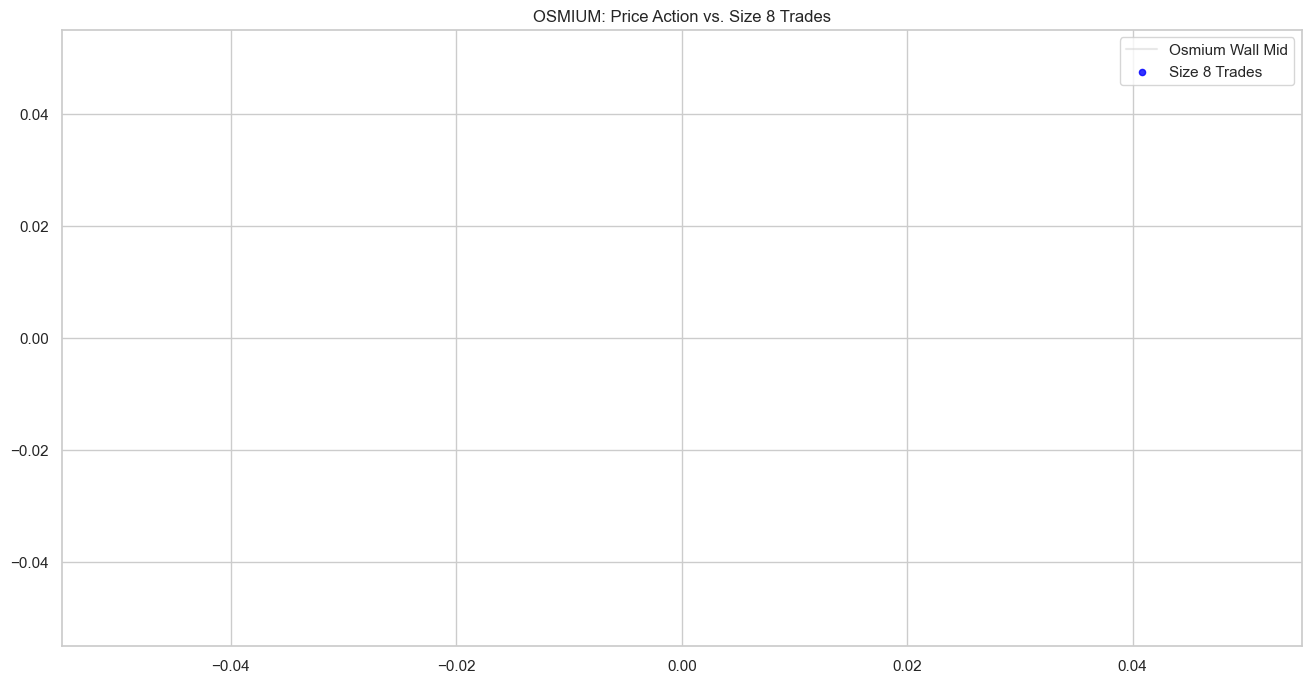

--- Statistical Profile for OSMIUM Size 8 ---


,ret_5,ret_10,ret_20
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


Correlation between entry percentile and 10-tick return: nan


In [7]:
# 1. Isolate Osmium
PRODUCT_NAME = 'OSMIUM'
osmium_prices = prices[prices['product'] == PRODUCT_NAME].copy()
osmium_trades = trades[trades['symbol'] == PRODUCT_NAME].copy()

# 2. Calculate Forward Returns for Osmium
# Let's look at 5, 10, and 20 ticks ahead to see the "decay" of the signal
for window in [5, 10, 20]:
    osmium_prices[f'ret_{window}'] = osmium_prices['wall_mid'].shift(-window) - osmium_prices['wall_mid']

# 3. Merge trades with the specific Osmium return data
osmium_analysis = osmium_trades.merge(
    osmium_prices[['day', 'timestamp', 'wall_mid', 'ret_5', 'ret_10', 'ret_20']],
    on=['day', 'timestamp'],
    how='inner'
)

# 4. Visualize Osmium Price Action with Size 8 Highlights
plt.figure(figsize=(16, 8))
plt.plot(osmium_prices.index, osmium_prices['wall_mid'], color='lightgray', alpha=0.5, label='Osmium Wall Mid')

# Highlight Size 8
size_8 = osmium_analysis[osmium_analysis['quantity'] == 8]
plt.scatter(size_8.index, size_8['price'], color='blue', label='Size 8 Trades', s=20, alpha=0.8)

# Highlight Daily Extremes (To see if Size 8 likes the edges)
for day in osmium_prices['day'].unique():
    day_data = osmium_prices[osmium_prices['day'] == day]
    plt.axhline(day_data['wall_mid'].max(), color='red', linestyle='--', alpha=0.3)
    plt.axhline(day_data['wall_mid'].min(), color='green', linestyle='--', alpha=0.3)

plt.title(f"{PRODUCT_NAME}: Price Action vs. Size 8 Trades")
plt.legend()
plt.show()

# 5. Statistical Deep Dive into Size 8
print(f"--- Statistical Profile for {PRODUCT_NAME} Size 8 ---")
s8_stats = osmium_analysis[osmium_analysis['quantity'] == 8][['ret_5', 'ret_10', 'ret_20']].describe()
display(s8_stats)

# Correlation check: Does the price at which size 8 trades occur 
# relative to the day's range predict the return?
osmium_analysis['rel_price'] = (osmium_analysis['price'] - osmium_analysis.groupby('day')['price'].transform('min')) / \
                               (osmium_analysis.groupby('day')['price'].transform('max') - osmium_analysis.groupby('day')['price'].transform('min'))

size_8_corr = osmium_analysis[osmium_analysis['quantity'] == 8][['rel_price', 'ret_10']].corr().iloc[0,1]
print(f"Correlation between entry percentile and 10-tick return: {size_8_corr:.4f}")